# Packet and Flowlet Direction Comparison

This notebook compares incoming vs outgoing traffic at two levels:

- **Packet totals** for `llm` and `non_llm` traffic
- **Flowlet counts** for `non_llm` traffic, to compare with the LLM flowlet-direction result from the paper

Because the same base captures appear at multiple flowlet thresholds, the primary plots below use a **single threshold** at a time so captures are not counted multiple times.


In [13]:
import json
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="crest")


def load_latest_snapshot() -> tuple[Path, pd.DataFrame]:
    candidate_roots = [
        Path("data-pipeline/data/snapshots"),
        Path("../data-pipeline/data/snapshots"),
    ]

    snapshots_root = None
    snapshot_dirs = []
    for candidate in candidate_roots:
        candidate_dirs = sorted(candidate.glob("snapshot_*"), reverse=True)
        if candidate_dirs:
            snapshots_root = candidate
            snapshot_dirs = candidate_dirs
            break

    if not snapshot_dirs or snapshots_root is None:
        checked = ", ".join(str(path.resolve()) for path in candidate_roots)
        raise FileNotFoundError(f"No snapshots found. Checked: {checked}")

    snapshot_dir = snapshot_dirs[0]
    captures_dir = snapshot_dir / "captures"
    capture_files = sorted(captures_dir.glob("*.json"))

    rows = []
    for fpath in capture_files:
        with open(fpath, "r", encoding="utf-8") as f:
            doc = json.load(f)

        cap_id = str(doc.get("_id", fpath.stem))
        file_path = doc.get("file_path", cap_id)
        match = re.search(r"_(\d+\.?\d*)$", file_path)
        threshold = doc.get("threshold")
        base_name = file_path[:match.start()] if match else file_path

        for fl in doc.get("flowlets") or []:
            fk = fl.get("flow_key", {})
            rows.append({
                "capture_id": cap_id,
                "base_capture": base_name,
                "threshold": threshold,
                "file_path": file_path,
                "traffic_class": fl.get("traffic_class"),
                "llm_name": fl.get("llm_name"),
                "outgoing": fl.get("outgoing"),
                "direction_encoded": fl.get("direction_encoded", 0),
                "flowlet_id": fl.get("flowlet_id"),
                "duration": fl.get("duration", 0),
                "packet_count": fl.get("packet_count", 0),
                "total_bytes": fl.get("total_bytes", 0),
                "packet_size_mean": fl.get("packet_size_mean"),
                "packet_size_std": fl.get("packet_size_std"),
                "inter_packet_time_mean": fl.get("inter_packet_time_mean"),
                "inter_packet_time_std": fl.get("inter_packet_time_std"),
                "src_ip": fk.get("src_ip"),
                "dst_ip": fk.get("dst_ip"),
                "protocol": fk.get("protocol"),
            })

    df = pd.DataFrame(rows)
    return snapshot_dir, df


snapshot_dir, df = load_latest_snapshot()
available_thresholds = sorted(df["threshold"].dropna().unique().tolist())
print(f"Using snapshot: {snapshot_dir.name}")
print(f"Loaded {len(df):,} flowlets from {df['capture_id'].nunique():,} captures")
print(f"Available thresholds: {available_thresholds}")
df.head()


Using snapshot: snapshot_20260416_163332
Loaded 674,852 flowlets from 117 captures
Available thresholds: [0.05, 0.1, 0.2]


,capture_id,base_capture,threshold,file_path,traffic_class,llm_name,outgoing,direction_encoded,flowlet_id,duration,packet_count,total_bytes,packet_size_mean,packet_size_std,inter_packet_time_mean,inter_packet_time_std,src_ip,dst_ip,protocol
0,3-19-26-non-llm-10-min_0.05,3-19-26-non-llm-10-min,0.05,3-19-26-non-llm-10-min_0.05,non_llm,None,None,0,1,0.006761,19,16727,880.368421,612.043318,0.000376,0.000690,17.250.96.198,172.25.168.55,6
1,3-19-26-non-llm-10-min_0.05,3-19-26-non-llm-10-min,0.05,3-19-26-non-llm-10-min_0.05,non_llm,None,None,0,2,0.007671,3,2126,708.666667,689.006047,0.003835,0.005402,172.25.168.55,17.250.96.198,6
2,3-19-26-non-llm-10-min_0.05,3-19-26-non-llm-10-min,0.05,3-19-26-non-llm-10-min_0.05,non_llm,None,None,0,3,0.028227,92,81313,883.836957,584.693613,0.000310,0.001028,17.250.96.198,172.25.168.55,6
3,3-19-26-non-llm-10-min_0.05,3-19-26-non-llm-10-min,0.05,3-19-26-non-llm-10-min_0.05,non_llm,None,None,0,1,0.014345,3,1210,403.333333,557.373603,0.007173,0.010064,172.25.168.55,98.124.193.103,6
4,3-19-26-non-llm-10-min_0.05,3-19-26-non-llm-10-min,0.05,3-19-26-non-llm-10-min_0.05,non_llm,None,None,0,2,0.038493,6,2417,402.833333,497.761556,0.007699,0.010234,172.25.168.55,98.124.193.103,6


In [9]:
# Pick a single threshold to avoid counting the same base capture multiple times.
# Change this to 0.05 or 0.1 if you want to compare a different flowlet construction.
ANALYSIS_THRESHOLD = 0.2

if ANALYSIS_THRESHOLD not in available_thresholds:
    raise ValueError(f"Threshold {ANALYSIS_THRESHOLD} not present. Choose from {available_thresholds}.")

plot_df = df[df["threshold"] == ANALYSIS_THRESHOLD].copy()
plot_df = plot_df[plot_df["traffic_class"].isin(["llm", "non_llm"])].copy()
plot_df["direction"] = plot_df["outgoing"].map({True: "Outgoing", False: "Incoming"})
plot_df = plot_df.dropna(subset=["direction"])
plot_df["traffic_class_label"] = plot_df["traffic_class"].map({"llm": "LLM", "non_llm": "Non-LLM"})

packet_direction = (
    plot_df.groupby(["traffic_class", "traffic_class_label", "direction"], as_index=False)["packet_count"]
    .sum()
)

flowlet_direction = (
    plot_df.groupby(["traffic_class", "traffic_class_label", "direction"], as_index=False)
    .size()
    .rename(columns={"size": "flowlet_count"})
)

llm_flowlet_direction = (
    flowlet_direction[flowlet_direction["traffic_class"] == "llm"]
    [["traffic_class_label", "direction", "flowlet_count"]]
    .reset_index(drop=True)
)

non_llm_flowlet_direction = (
    flowlet_direction[flowlet_direction["traffic_class"] == "non_llm"]
    [["traffic_class_label", "direction", "flowlet_count"]]
    .reset_index(drop=True)
)

packet_summary = (
    packet_direction
    .pivot(index="traffic_class_label", columns="direction", values="packet_count")
    .fillna(0)
)
packet_summary["Total"] = packet_summary.sum(axis=1)
packet_summary["Outgoing share"] = packet_summary["Outgoing"] / packet_summary["Total"]
packet_summary["Incoming share"] = packet_summary["Incoming"] / packet_summary["Total"]
packet_summary["Outgoing / Incoming"] = packet_summary["Outgoing"] / packet_summary["Incoming"]

flowlet_summary = (
    flowlet_direction
    .pivot(index="traffic_class_label", columns="direction", values="flowlet_count")
    .fillna(0)
)
flowlet_summary["Total"] = flowlet_summary.sum(axis=1)
flowlet_summary["Outgoing share"] = flowlet_summary["Outgoing"] / flowlet_summary["Total"]
flowlet_summary["Incoming share"] = flowlet_summary["Incoming"] / flowlet_summary["Total"]
flowlet_summary["Outgoing / Incoming"] = flowlet_summary["Outgoing"] / flowlet_summary["Incoming"]

display(packet_summary.style.format({
    "Incoming": "{:,.0f}",
    "Outgoing": "{:,.0f}",
    "Total": "{:,.0f}",
    "Outgoing share": "{:.1%}",
    "Incoming share": "{:.1%}",
    "Outgoing / Incoming": "{:.2f}x",
}).set_caption(f"Packet totals at threshold = {ANALYSIS_THRESHOLD:g} s"))

display(flowlet_summary.style.format({
    "Incoming": "{:,.0f}",
    "Outgoing": "{:,.0f}",
    "Total": "{:,.0f}",
    "Outgoing share": "{:.1%}",
    "Incoming share": "{:.1%}",
    "Outgoing / Incoming": "{:.2f}x",
}).set_caption(f"Flowlet counts at threshold = {ANALYSIS_THRESHOLD:g} s"))


direction,Incoming,Outgoing,Total,Outgoing share,Incoming share,Outgoing / Incoming
traffic_class_label,,,,,,
LLM,"619,208","1,138,977","1,758,185",64.8%,35.2%,1.84x
Non-LLM,"824,126","21,984","846,110",2.6%,97.4%,0.03x


direction,Incoming,Outgoing,Total,Outgoing share,Incoming share,Outgoing / Incoming
traffic_class_label,,,,,,
LLM,"38,758","40,535","79,293",51.1%,48.9%,1.05x
Non-LLM,"46,916","3,084","50,000",6.2%,93.8%,0.07x


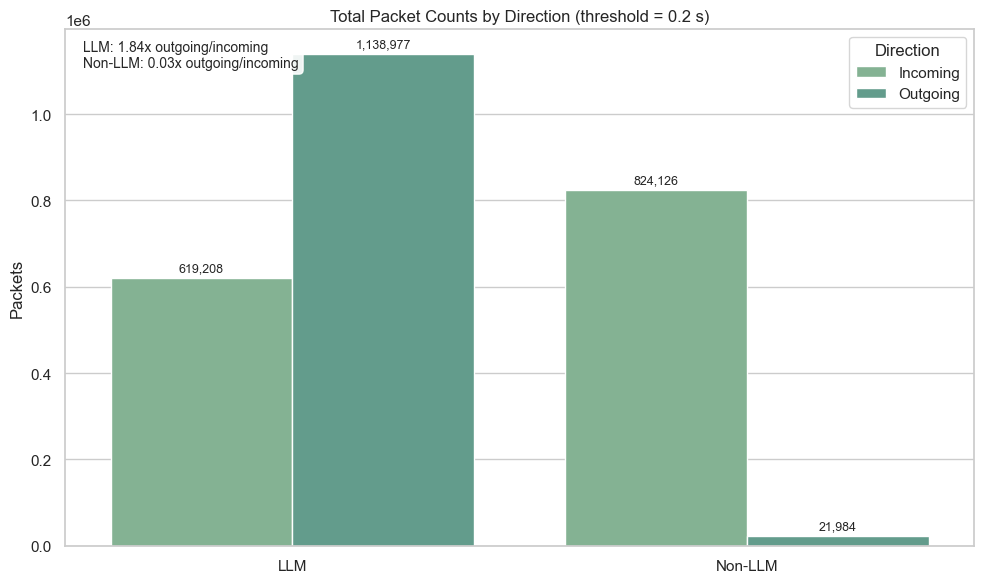

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

packet_plot = packet_direction.copy()
packet_plot["direction"] = pd.Categorical(packet_plot["direction"], ["Incoming", "Outgoing"], ordered=True)
packet_plot["traffic_class_label"] = pd.Categorical(packet_plot["traffic_class_label"], ["LLM", "Non-LLM"], ordered=True)
packet_plot = packet_plot.sort_values(["traffic_class_label", "direction"])

sns.barplot(
    data=packet_plot,
    x="traffic_class_label",
    y="packet_count",
    hue="direction",
    ax=ax,
)
ax.set_title(f"Total Packet Counts by Direction (threshold = {ANALYSIS_THRESHOLD:g} s)")
ax.set_xlabel("")
ax.set_ylabel("Packets")
ax.legend(title="Direction")

for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=3, fontsize=9)

ratio_text = []
for class_label in ["LLM", "Non-LLM"]:
    incoming = packet_summary.loc[class_label, "Incoming"]
    outgoing = packet_summary.loc[class_label, "Outgoing"]
    ratio = outgoing / incoming if incoming else float("inf")
    ratio_text.append(f"{class_label}: {ratio:.2f}x outgoing/incoming")

ax.text(
    0.02,
    0.98,
    "\n".join(ratio_text),
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9},
)

plt.tight_layout()
plt.show()


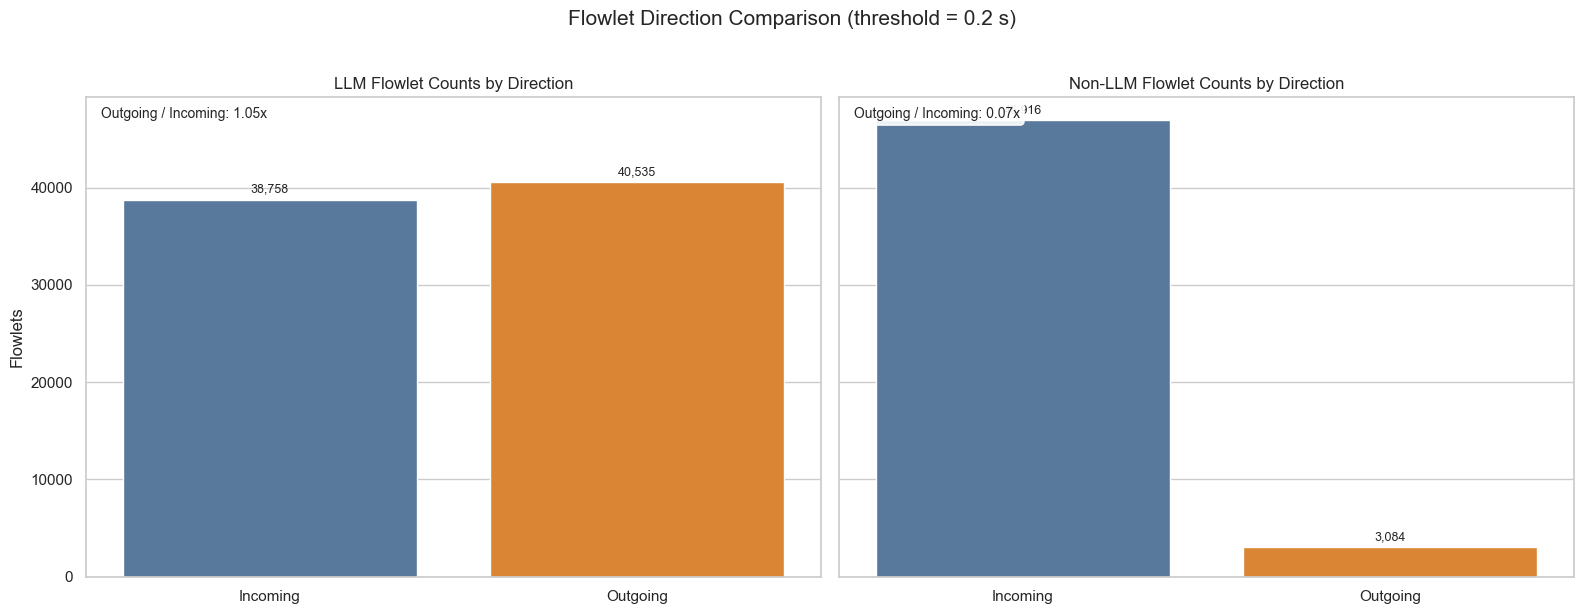

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

flowlet_plots = [
    (axes[0], llm_flowlet_direction.copy(), "LLM Flowlet Counts by Direction"),
    (axes[1], non_llm_flowlet_direction.copy(), "Non-LLM Flowlet Counts by Direction"),
]

for ax, flowlet_plot, title in flowlet_plots:
    flowlet_plot["direction"] = pd.Categorical(flowlet_plot["direction"], ["Incoming", "Outgoing"], ordered=True)
    flowlet_plot = flowlet_plot.sort_values("direction")

    sns.barplot(
        data=flowlet_plot,
        x="direction",
        y="flowlet_count",
        order=["Incoming", "Outgoing"],
        palette=["#4C78A8", "#F58518"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Flowlets")

    for container in ax.containers:
        ax.bar_label(container, fmt="{:,.0f}", padding=3, fontsize=9)

    class_label = flowlet_plot["traffic_class_label"].iloc[0]
    ratio = flowlet_summary.loc[class_label, "Outgoing / Incoming"]
    ax.text(
        0.02,
        0.98,
        f"Outgoing / Incoming: {ratio:.2f}x",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=10,
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9},
    )

fig.suptitle(f"Flowlet Direction Comparison (threshold = {ANALYSIS_THRESHOLD:g} s)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


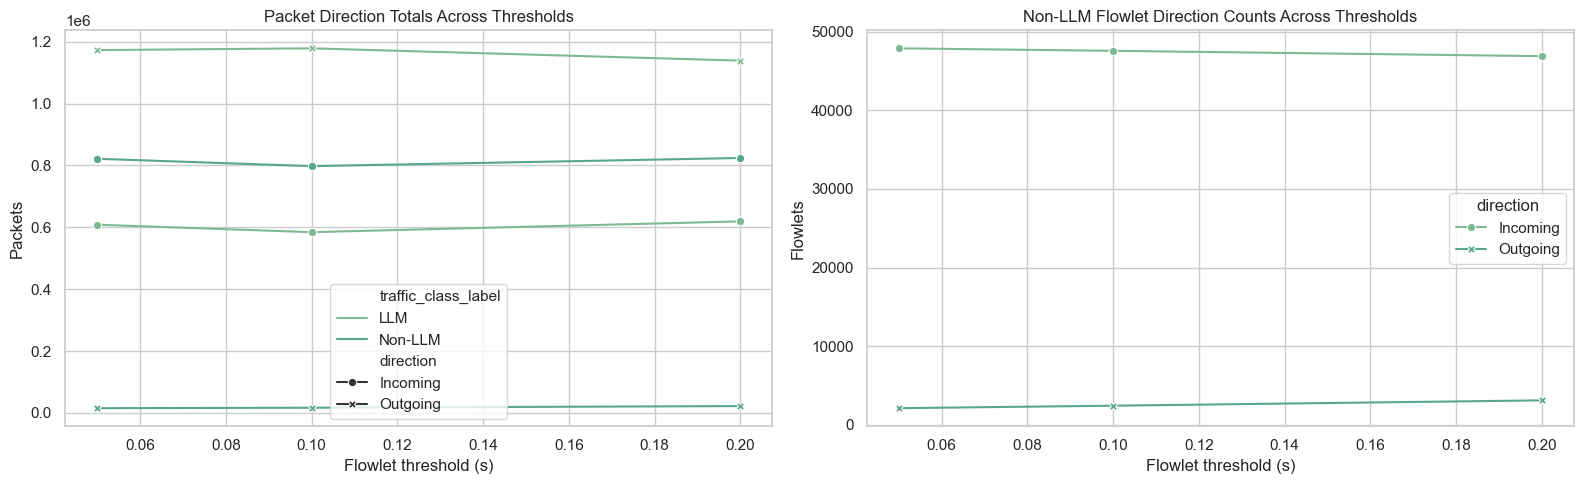

In [12]:
# Optional robustness view: inspect whether the directional pattern changes across thresholds.
robust_packet_direction = (
    df[df["traffic_class"].isin(["llm", "non_llm"])]
    .assign(
        direction=lambda d: d["outgoing"].map({True: "Outgoing", False: "Incoming"}),
        traffic_class_label=lambda d: d["traffic_class"].map({"llm": "LLM", "non_llm": "Non-LLM"}),
    )
    .dropna(subset=["direction", "threshold"])
    .groupby(["threshold", "traffic_class_label", "direction"], as_index=False)["packet_count"]
    .sum()
)

robust_non_llm_flowlets = (
    df[df["traffic_class"] == "non_llm"]
    .assign(direction=lambda d: d["outgoing"].map({True: "Outgoing", False: "Incoming"}))
    .dropna(subset=["direction", "threshold"])
    .groupby(["threshold", "direction"], as_index=False)
    .size()
    .rename(columns={"size": "flowlet_count"})
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(
    data=robust_packet_direction,
    x="threshold",
    y="packet_count",
    hue="traffic_class_label",
    style="direction",
    markers=True,
    dashes=False,
    ax=axes[0],
)
axes[0].set_title("Packet Direction Totals Across Thresholds")
axes[0].set_xlabel("Flowlet threshold (s)")
axes[0].set_ylabel("Packets")

sns.lineplot(
    data=robust_non_llm_flowlets,
    x="threshold",
    y="flowlet_count",
    hue="direction",
    style="direction",
    markers=True,
    dashes=False,
    ax=axes[1],
)
axes[1].set_title("Non-LLM Flowlet Direction Counts Across Thresholds")
axes[1].set_xlabel("Flowlet threshold (s)")
axes[1].set_ylabel("Flowlets")

plt.tight_layout()
plt.show()


### How to read these plots

- If `LLM` traffic shows a much stronger outgoing-vs-incoming packet imbalance than `non_llm`, that suggests the classifier may be picking up request/response asymmetry at the packet level, not just the number of flowlets.
- The `non_llm` flowlet-direction plot gives you the direct baseline to compare against the LLM flowlet-direction result you already have from the paper.
- If you want to stress-test the conclusion, rerun the notebook at `0.05`, `0.1`, and `0.2` seconds and compare how stable the directional ratios are.
